In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [2]:
# step 1 - download the dataset
df = pd.read_csv(r'bank.csv', sep=';')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
# step 2 - explore the dataset (rows, columns, feature types, missing values, summary statistics).
row,col= df.shape
print('No. of rows in the dataset:', row)
print('No. of columns in the dataset:', col)

No. of rows in the dataset: 4521
No. of columns in the dataset: 17


In [5]:
print('Features and their data types:\n')
df.dtypes

Features and their data types:



age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [6]:
print('Missing values in the dataset:',df.isnull().sum().sum())

Missing values in the dataset: 0


In [7]:
print('Summary statistics:')
df.describe()

Summary statistics:


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [8]:
# step 4 - Perform train-test split and build machine learning models (start with logistic regression,
# then try other classifiers like Random Forest).

X = df.drop(columns=['y'])   # training features
y = df['y'].map({'yes': 1, 'no': 0})  # target variable

In [9]:
#categorical columns
cat= X.select_dtypes(include=["object"]).columns.tolist()

#performing one hot encoding to transform all the categorical values into numerical
X_cat = pd.get_dummies(X[cat], drop_first=True)

In [10]:
#numerical columns
num= X.select_dtypes(include=[np.number]).columns.tolist()

#scaling those numerical columns
scaler= StandardScaler()
X_num=pd.DataFrame(scaler.fit_transform(X[num]), columns=num)

X=pd.concat([X_num,X_cat], axis=1)

In [11]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# Logistic regression
logr= LogisticRegression(max_iter=1000, solver="liblinear")
logr.fit(X_train, y_train)

y_pred_log = logr.predict(X_test)
y_proba_log = logr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       801
           1       0.55      0.28      0.37       104

    accuracy                           0.89       905
   macro avg       0.73      0.62      0.65       905
weighted avg       0.87      0.89      0.87       905

Confusion Matrix:
 [[777  24]
 [ 75  29]]
ROC-AUC: 0.8913977720157495


In [13]:
#Random classifier
rclf= RandomForestClassifier(n_estimators=100, random_state=42)
rclf.fit(X_train, y_train)

y_pred_rf= rclf.predict(X_test)
y_proba_rf= rclf.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       801
           1       0.53      0.25      0.34       104

    accuracy                           0.89       905
   macro avg       0.72      0.61      0.64       905
weighted avg       0.87      0.89      0.87       905

Confusion Matrix:
 [[778  23]
 [ 78  26]]
ROC-AUC: 0.8903774128493229


In [98]:
#trying out thresholds
threshold=[0.3,0.4,0.5]
for t in threshold:
    
    y_pred_t=(y_proba_rf>=t).astype(int) 
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:  {recall:.3f}\n")

Threshold: 0.3
Precision: 0.481
Recall:  0.625

Threshold: 0.4
Precision: 0.541
Recall:  0.442

Threshold: 0.5
Precision: 0.528
Recall:  0.269



In [15]:
f=df.drop(columns=['y']) 
features= f.columns.tolist()
print('All the features in the dataset:\n', features)

All the features in the dataset:
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [16]:
num= X.select_dtypes(include=[np.number]).columns.tolist()
print('All the numericals features:\n', num)

All the numericals features:
 ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [17]:
cat= X.select_dtypes(include=["object"]).columns.tolist()
print('All the categorical features:\n', cat)

All the categorical features:
 []


In [18]:
b=[]
for col in f:
    if f[col].nunique()==2:
        b.append(col)
        
print("All the binary features:\n", b)


All the binary features:
 ['default', 'housing', 'loan']


In [19]:
import warnings
warnings.filterwarnings("ignore")


y
no     4000
yes     521
Name: count, dtype: int64


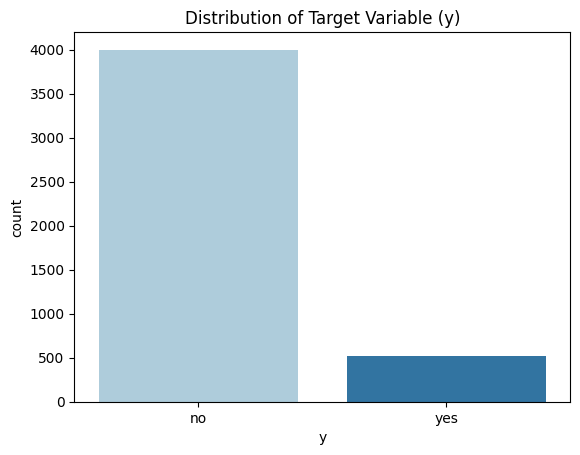

In [20]:
target_dist = df['y'].value_counts()
print(target_dist)

sns.countplot(x='y', data=df, palette='Paired')
plt.title("Distribution of Target Variable (y)")
plt.show()

In [21]:
print('Most frequent job category: ',df['job'].mode()[0])

Most frequent job category:  management


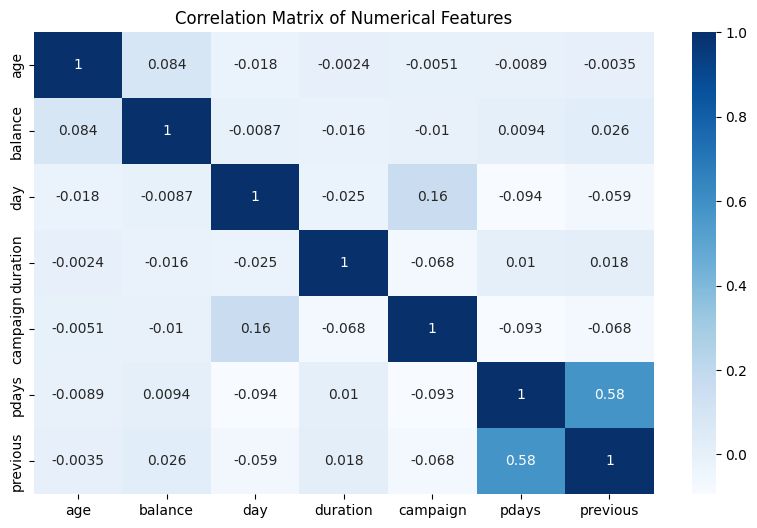

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


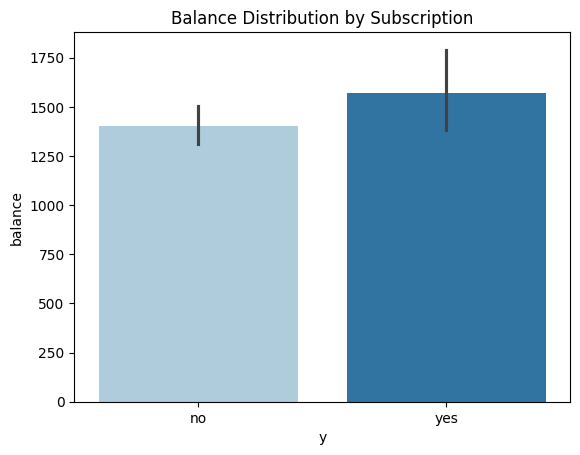

In [102]:

sns.barplot(x='y', y='balance', data=df, palette='Paired')
plt.title("Balance Distribution by Subscription")
plt.show()

education
tertiary     14.296296
secondary    10.624458
unknown      10.160428
primary       9.439528
Name: y, dtype: float64


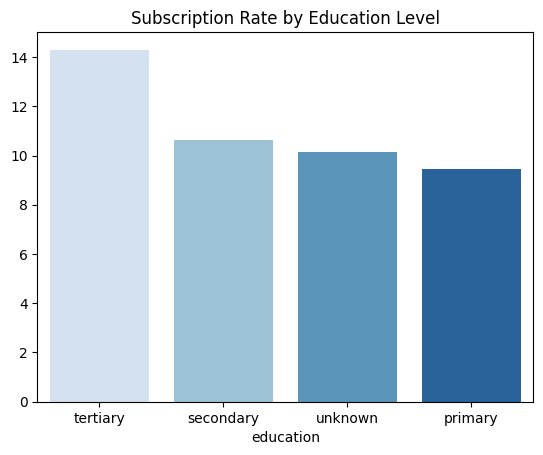

In [24]:
edu_rate = (df['y']== 'yes').groupby(df['education']).mean().sort_values(ascending=False)*100
print(edu_rate)
sns.barplot(x=edu_rate.index, y=edu_rate.values, palette='Blues')
plt.title("Subscription Rate by Education Level")
plt.show()


In [25]:
print('The education group with highest subscription rate is: ', edu_rate.idxmax())

The education group with highest subscription rate is:  tertiary


In [135]:
print('Before one-hot encoding:\n')
print(df['marital'])

m= pd.get_dummies(df['marital'])
print('\nAfter one-hot encoding:\n')
m

Before one-hot encoding:

0       married
1       married
2        single
3       married
4       married
         ...   
4516    married
4517    married
4518    married
4519    married
4520     single
Name: marital, Length: 4521, dtype: object

After one-hot encoding:



,divorced,married,single
0,False,True,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False
...,...,...,...
4516,False,True,False
4517,False,True,False
4518,False,True,False
4519,False,True,False


In [27]:
print(f'Train: {len(X_train)} samples\nTest: {len(X_test)} samples')

Train: 3616 samples
Test: 905 samples


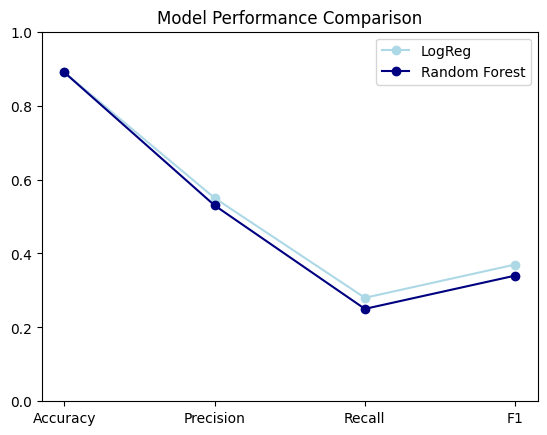

In [74]:
metrics = {
    "Logistic Regression": [0.89, 0.55, 0.28, 0.37],
    "Random Forest": [0.89, 0.53, 0.25, 0.34]
}

labels = ["Accuracy","Precision","Recall","F1"]

plt.plot(labels, metrics["Logistic Regression"], marker='o', label="LogReg", color='lightblue')
plt.plot(labels, metrics["Random Forest"], marker='o', label="Random Forest",color='navy')
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()


AUC Score: 0.891


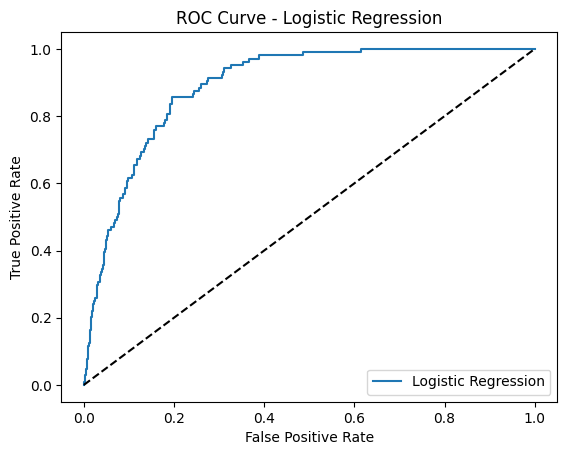

In [133]:
y_proba_log = logr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

auc_score = roc_auc_score(y_test, y_proba_log)
print(f"AUC Score: {auc_score:.3f}")

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line (random baseline)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
